<a href="https://colab.research.google.com/github/lelyashashlyk/DataScienceLearning/blob/main/statistics/statistics_lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Калькулятор расчета вероятности для случайной величины

https://gallery.shinyapps.io/dist_calc/

# Симулятор Центральной Предельной Теоремы

https://gallery.shinyapps.io/CLT_mean/

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from scipy.stats import norm

In [2]:
z_value = 4.585109509
probability = norm.cdf(z_value)
probability

np.float64(0.9999977312572335)

In [3]:
def get_middle(z1, z2):
  return norm.cdf(z2) - norm.cdf(z1)

def both_tails(z1, z2):
  return norm.cdf(z1) + 1 - norm.cdf(z2)

In [4]:
get_middle(-4, 4)

np.float64(0.9999366575163338)

In [5]:
both_tails(-4.585109509, 4.585109509)

np.float64(4.537485533084862e-06)

# Before

Перед началом выполнения заданий будет полезным "поиграться" с симулятором ЦПТ.

# Task_1

Рассмотрим numpy метод `np.random.choice(arr, size)`. Он позволяет из массива случайным образом отобрать заданное количество элементов, при том что какие-то элементы могут случайно повторяться.

Дан массив `arr`. Сделайте из него случайную выборку размером 100 и сравните среднее и стандартное отклонение выборки и исходного массива. Укладывается ли выборочное среднее в 95% доверительный интервал исходной выборки?

In [6]:
arr = np.random.normal(100, 10, 10000)

In [7]:
size = 100
sample = np.random.choice(arr, size)
print(arr.mean().item(), arr.std().item(), sample.mean().item(), sample.std().item())

se = sample.std().item()/np.sqrt(size)

left = sample.mean().item() - se * 1.96
right = sample.mean().item() + 1.96 * se

print('доверительный интервал от ', left.round(2).item(), ' до ', right.round(2).item())

100.06898118381437 9.977519501503608 100.81113428317336 10.579538728088087
доверительный интервал от  98.74  до  102.88


# Task_2

Дана выборка из Генеральной Совокупности, о которой мы ничего не знаем. Определите границы интервала, в котором будет находится среднее ГС с вероятностью 95%, и сохраните их в переменные
* left
* right



In [8]:
sample = np.random.normal(20, 5, 100)

In [9]:
n = 100

se = sample.std()/np.sqrt(n)

left = sample.mean()  - se * 1.96
right = sample.mean()  + se * 1.96

print('доверительный интервал от ', left.round(2).item(), ' до ', right.round(2).item())

доверительный интервал от  19.73  до  21.66


# Task_3

Дан набор нормально распределенных данных. Напишите функцию, которая из этого набора данных делает 100 случайных выборок заданного объема и возвращает массив со всеми выборочными средними. Функция получает 2 аргумента
* Массив
* Объем каждой выборки.

Постройте кривую распределения всех средних. Вычислите Среднее всех средних и сравните его со средним исходной выборки. Вычислите стандартное отклонение полученного массива, которое и будет являться "стандартной ошибкой среднего".

In [10]:
arr = np.random.normal(20, 5, 10000)

In [11]:
def get_samples(arr, n):
  return [np.random.choice(arr, n) for i in range(100)]

In [12]:
samples = get_samples(arr, 30)
samples_mean = [i.mean().item() for i in samples]

Text(0.5, 0, 'Mean')

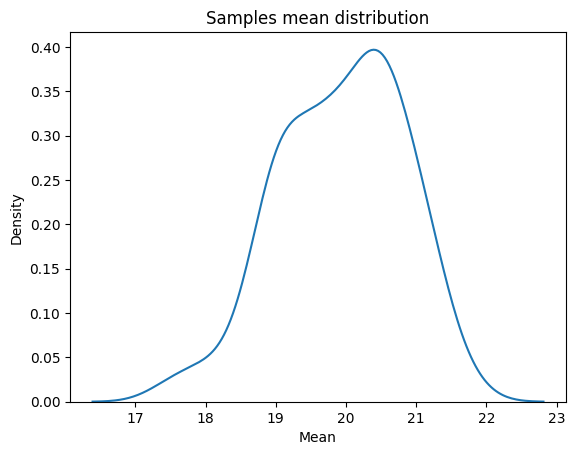

In [13]:
sns.kdeplot(samples_mean)
plt.title('Samples mean distribution')
plt.xlabel('Mean')

In [14]:
np.mean(samples_mean).item(), arr.mean().item() # mean of samples means

(19.933847557341302, 20.040938515696634)

In [15]:
SE = np.std(samples_mean) / np.sqrt(len(samples_mean))
SE

np.float64(0.08835717860769948)

# Task_4

Примените написанную в предыдущем таске функцию уже к другому набору данных, распределение которого РАВНОМЕРНО. Постройте кривую распределения для всех средних и оцените его близость к нормальному.

In [16]:
arr = np.random.uniform(20, 5, 10000)

In [17]:
samples2 = get_samples(arr, 30)

<Axes: ylabel='Density'>

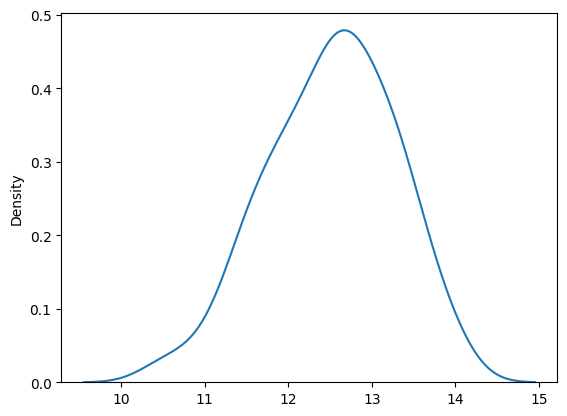

In [18]:
sample_means2 = [np.mean(i) for i in samples2]
sns.kdeplot(sample_means2)

# Task_5

У нас онлайн продукт и нам очень важно отслеживать посещаемость нашего сайта клиентами, так как посещаемость напрямую влияет на покупки. Перед нами статистика по количеству посещений за месяц в виде массива `visits` из 1000 наблюдений. Каждый клиент - это отдельное наблюдение. Будем этот набор данных считать генеральной совокупностью, у которой:
* mean = 20
* std = 5

Мы решили провести эксперимент и проверить, повлияет ли реклама нашего продукта на посещаемость. Для этого мы отобрали контрольную группу из 100 человек и разослали им рекламу. Затем мы посчитали их посещаемость за месяц. Сформулируйте гипотезы и оцените эффективность рекламной акции.

In [19]:
visits = np.random.normal(20, 5, 1000).round()

In [20]:
visits.mean().item(), visits.std().item()

(19.978, 4.8389581523299)

In [21]:
control_group = np.array([21., 24., 25., 26., 22., 16., 27., 18., 21., 18., 18., 28., 20.,
                          24., 18., 20., 24., 24., 17., 21., 20., 26., 15., 29., 23., 22.,
                          29., 20., 21., 22., 20., 17., 19., 25., 25., 21., 26., 22., 26.,
                          20., 21., 25., 21., 20., 20., 25., 19., 22., 26., 21., 22., 26.,
                          23., 25., 21., 23., 16., 17., 22., 30., 19., 27., 25., 19., 18.,
                          19., 19., 18., 25., 14., 22., 26., 21., 21., 23., 20., 20., 25.,
                          17., 26., 30., 28., 19., 25., 23., 19., 16., 12., 16., 20., 13.,
                          18., 27., 24., 27., 16., 21., 27., 20., 27.])

In [22]:
m = control_group.mean().item()
s = control_group.std().item()
n = len(control_group)
m, s, n

(21.77, 3.8777699777062593, 100)

In [23]:
se = s/np.sqrt(n)
se

np.float64(0.3877769977706259)

In [24]:
left = m - se * 1.96
right = m + se * 1.96

print('доверительный интервал от ', left.round(2).item(), ' до ', right.round(2).item())

доверительный интервал от  21.01  до  22.53


In [25]:
visits.mean().item()

19.978

попробуем найти доверительный интервал для 99.7% вероятности (3 сигмы)

In [26]:
left = m - se * 3
right = m + se * 3

print('доверительный интервал от ', left.round(2).item(), ' до ', right.round(2).item())

доверительный интервал от  20.61  до  22.93


In [27]:
visits.mean().item()

19.978

### Проверка гипотез

H0: разницы нет, выборка взята из ген.совокупности

In [28]:
z = (control_group.mean() - visits.mean())/ (control_group.std()/np.sqrt(len(control_group)))
z

np.float64(4.621212733871297)

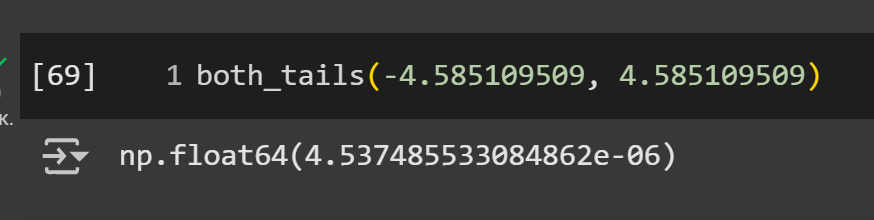

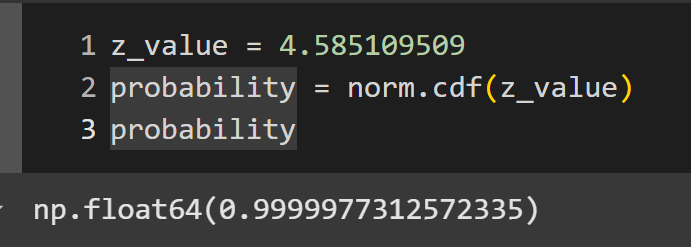

# Task_6

Давайте решим задачу в контексте изучения рынка земельных участков Кыргызстана. Известно, что стоимости участков в бишкеке имеют следующие статистические меры:
* mean = 37660 USD
* std = 96159 USD

Даны две выборки со стоимости участков для двух городов. Какой из этих городов c большей вероятностью является Бишкеком?

In [29]:
city_1 = np.array([2.130180e+04, 1.431639e+05, 1.402712e+05, 1.504350e+04,
                   8.002000e+03, 2.300600e+04, 1.000000e+04, 1.398380e+04,
                    2.675420e+04, 2.000000e+03, 3.600000e+04, 3.500000e+04,
                    1.431639e+05, 2.001410e+04, 2.102220e+04, 2.501480e+04,
                    6.250300e+03, 4.120070e+04, 5.969810e+04, 2.362000e+03,
                    8.550000e+04, 1.000000e+06, 1.498960e+04, 3.531490e+04,
                    6.000000e+03, 5.386000e+03, 2.501820e+04, 1.182628e+05,
                    1.200000e+05, 1.746170e+04, 1.149950e+04, 8.562600e+03,
                    1.000000e+03, 1.424220e+04, 8.507870e+04, 2.700000e+04,
                    1.700480e+04, 1.697550e+04, 5.513400e+03, 3.599800e+03,
                    2.900000e+04, 1.193000e+02, 3.000000e+04, 4.493400e+04,
                    3.611080e+04, 1.500000e+04, 6.700000e+03, 1.662900e+03,
                    1.257840e+04, 4.481100e+03, 1.050000e+05, 6.000000e+03,
                    1.608400e+03, 8.401590e+04, 6.000000e+04, 9.882100e+03,
                    2.358500e+03, 1.473680e+04, 1.950770e+04, 6.000000e+04,
                    1.718900e+03, 3.000000e+03, 5.999280e+04, 4.412300e+03,
                    5.000000e+04, 5.191470e+04, 1.600620e+04, 2.812837e+05,
                    1.431930e+04, 1.500000e+04, 2.500000e+04, 9.041620e+04,
                    4.120100e+03, 8.215600e+03, 1.758790e+04, 3.001350e+04,
                    2.499910e+04, 7.150298e+05, 1.000000e+04, 2.099120e+04,
                    1.103150e+04, 4.000100e+04, 1.005100e+03, 4.422480e+04,
                    2.000040e+04, 5.246000e+03, 1.201230e+04, 2.700000e+03,
                    2.800000e+05, 2.004300e+04, 3.500000e+04, 2.443690e+04,
                    7.158800e+03, 1.886930e+04, 3.096000e+04, 8.403530e+04,
                    1.351000e+05, 1.200100e+03, 1.018990e+04, 1.500000e+04])

In [30]:
city_2 = np.array([ 37088. ,   8500. ,  28260.2,   7516.1,    999.9,   3000.
                   ,40600. ,  46000. ,   2779.1,  56813.3,   1686.6,  10313.2,
                  10613.2,   7286. ,  15000. ,   1512.4,  14501.2,  94126.2,
                  46998. ,  24022.8,  19000. ,  25000. ,  15956.9,   6000.1,
                  12165.5,   5000. ,  12699.7,  37000. ,  18899.7,  29562.9,
                  9621.2,  46799.2, 265311. ,  34534.5,  20000.3,  47615.7,
                  60989.7,  25000. ,   7015.7,  20000. ,  27924.1,  22992.9,
                    429.5,  16000. ,  23732.5,  27924.1,  19986. ,   8272.3,
                  4299.9,   9396.2,  79948.1,   3507.8,  26000. ,   2965.7,
                  26556.9,  22000. ,  12999.3,  14065.1,  55349.8,   4507.1,
                  16235.6,  24175.2, 119457.2,  29390.1,   5000. ,  22000. ,
                  6280.1, 150604.6,  25048.2,   7175. ,  23003.9,   4008.6,
                  50314.5,  37000. ,  14999.9,  57500. ,  80000. ,  20002. ,
                  19703.8,  11002.6,  14000. ,  23522. ,   2514.2,   2333.7,
                  40000. ,  44999.2,  10003.9,  85000.2,  78601. ,   4000. ,
                  59878.4,  22001. ,  31399.6,  20810. ,  49955.6,   1469.3,
                  4245.4,  11999.8,  17996.6,  26521.1])

In [31]:
bish_mean = 37660
bish_std = 96159

In [32]:
city_1.mean(), city_1.std()

(np.float64(51975.93800000001), np.float64(126643.34449350176))

In [33]:
city_2.mean(), city_2.std()

(np.float64(28587.979), np.float64(35064.26266996155))

In [34]:
from scipy.stats import ttest_1samp

In [35]:
ttest_1samp(se, visits.mean())

/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:1243: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:1243: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.int64(0))